1. EXTRAÇÃO E SUPER MOTOR TEMPORAL (12 VARIÁVEIS)...
2. TREINAMENTO (RANDOM FOREST) E RADAR QUANTITATIVO...


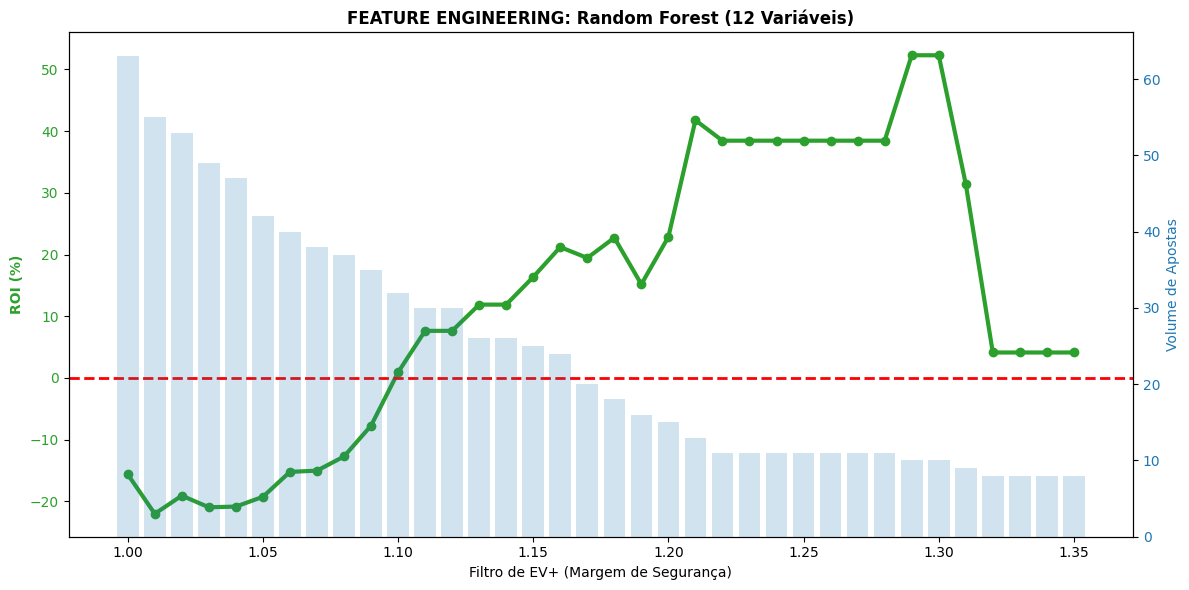

--------------------------------------------------
RESULTADO DO RANDOM FOREST (A Barreira da Multicolinearidade):
Melhor Filtro EV+: 1.29 |ROI Máximo: 52.30% | Entradas: 10


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV
import warnings
warnings.filterwarnings('ignore')

print("1. EXTRAÇÃO E SUPER MOTOR TEMPORAL (12 VARIÁVEIS)...")
# Extração Direta
url_fbref = "https://web.archive.org/web/20240525141014/https://fbref.com/en/comps/9/2023-2024/schedule/2023-2024-Premier-League-Scores-and-Fixtures"
df_fbref = pd.read_html(url_fbref, match="Wk")[0]
url_stats = "https://www.football-data.co.uk/mmz4281/2324/E0.csv"
df_mercado = pd.read_csv(url_stats)[['HomeTeam', 'AwayTeam', 'HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HF', 'AF', 'B365>2.5', 'B365<2.5']]

# Limpeza e Merge
df_limpo = df_fbref.dropna(subset=['Wk']).copy()
df_limpo = df_limpo[['Home', 'xG', 'Score', 'xG.1', 'Away']].rename(columns={'Home': 'Mandante', 'xG': 'xG_Mandante', 'Score': 'Placar', 'xG.1': 'xG_Visitante', 'Away': 'Visitante'}).dropna()
df_limpo['xG_Mandante'], df_limpo['xG_Visitante'] = pd.to_numeric(df_limpo['xG_Mandante'], errors='coerce'), pd.to_numeric(df_limpo['xG_Visitante'], errors='coerce')
df_limpo[['Gols_Mandante', 'Gols_Visitante']] = df_limpo['Placar'].str.extract(r'(\d+)[^\d]+(\d+)')
df_limpo = df_limpo.dropna()
df_limpo['Gols_Mandante'], df_limpo['Gols_Visitante'] = pd.to_numeric(df_limpo['Gols_Mandante']), pd.to_numeric(df_limpo['Gols_Visitante'])
df_limpo['Target_Over25'] = np.where((df_limpo['Gols_Mandante'] + df_limpo['Gols_Visitante']) > 2.5, 1, 0)

dicionario = {'Luton Town': 'Luton', 'Manchester City': 'Man City', 'Manchester Utd': 'Man United', 'Newcastle Utd': 'Newcastle', "Nott'ham Forest": "Nott'm Forest", 'Sheffield Utd': 'Sheffield United'}
df_limpo['Mandante_Odds'] = df_limpo['Mandante'].replace(dicionario)
df_limpo['Visitante_Odds'] = df_limpo['Visitante'].replace(dicionario)
df_super = pd.merge(df_limpo, df_mercado, left_on=['Mandante_Odds', 'Visitante_Odds'], right_on=['HomeTeam', 'AwayTeam'], how='inner')

# Motor Temporal (Calculando as 12 Dimensões)
equipas = pd.concat([df_super['Mandante'], df_super['Visitante']]).unique()
mochilas = {'xG': {eq: [] for eq in equipas}, 'xGA': {eq: [] for eq in equipas}, 'Remates': {eq: [] for eq in equipas}, 'Remates_Alvo': {eq: [] for eq in equipas}, 'Cantos': {eq: [] for eq in equipas}, 'Faltas': {eq: [] for eq in equipas}}
medias = {'Casa_xG_Ataque': [], 'Casa_xGA_Defesa': [], 'Fora_xG_Ataque': [], 'Fora_xGA_Defesa': [], 'Casa_Remates_5J': [], 'Fora_Remates_5J': [], 'Casa_RematesAlvo_5J': [], 'Fora_RematesAlvo_5J': [], 'Casa_Cantos_5J': [], 'Fora_Cantos_5J': [], 'Casa_Faltas_5J': [], 'Fora_Faltas_5J': []}

for index, jogo in df_super.iterrows():
    man, vis = jogo['Mandante'], jogo['Visitante']
    medias['Casa_xG_Ataque'].append(np.mean(mochilas['xG'][man][-5:]) if len(mochilas['xG'][man]) > 0 else 0)
    medias['Casa_xGA_Defesa'].append(np.mean(mochilas['xGA'][man][-5:]) if len(mochilas['xGA'][man]) > 0 else 0)
    medias['Fora_xG_Ataque'].append(np.mean(mochilas['xG'][vis][-5:]) if len(mochilas['xG'][vis]) > 0 else 0)
    medias['Fora_xGA_Defesa'].append(np.mean(mochilas['xGA'][vis][-5:]) if len(mochilas['xGA'][vis]) > 0 else 0)
    medias['Casa_Remates_5J'].append(np.mean(mochilas['Remates'][man][-5:]) if len(mochilas['Remates'][man]) > 0 else 0)
    medias['Fora_Remates_5J'].append(np.mean(mochilas['Remates'][vis][-5:]) if len(mochilas['Remates'][vis]) > 0 else 0)
    medias['Casa_RematesAlvo_5J'].append(np.mean(mochilas['Remates_Alvo'][man][-5:]) if len(mochilas['Remates_Alvo'][man]) > 0 else 0)
    medias['Fora_RematesAlvo_5J'].append(np.mean(mochilas['Remates_Alvo'][vis][-5:]) if len(mochilas['Remates_Alvo'][vis]) > 0 else 0)
    medias['Casa_Cantos_5J'].append(np.mean(mochilas['Cantos'][man][-5:]) if len(mochilas['Cantos'][man]) > 0 else 0)
    medias['Fora_Cantos_5J'].append(np.mean(mochilas['Cantos'][vis][-5:]) if len(mochilas['Cantos'][vis]) > 0 else 0)
    medias['Casa_Faltas_5J'].append(np.mean(mochilas['Faltas'][man][-5:]) if len(mochilas['Faltas'][man]) > 0 else 0)
    medias['Fora_Faltas_5J'].append(np.mean(mochilas['Faltas'][vis][-5:]) if len(mochilas['Faltas'][vis]) > 0 else 0)
    
    mochilas['xG'][man].append(jogo['xG_Mandante']); mochilas['xGA'][man].append(jogo['xG_Visitante'])
    mochilas['xG'][vis].append(jogo['xG_Visitante']); mochilas['xGA'][vis].append(jogo['xG_Mandante'])
    mochilas['Remates'][man].append(jogo['HS']); mochilas['Remates'][vis].append(jogo['AS'])
    mochilas['Remates_Alvo'][man].append(jogo['HST']); mochilas['Remates_Alvo'][vis].append(jogo['AST'])
    mochilas['Cantos'][man].append(jogo['HC']); mochilas['Cantos'][vis].append(jogo['AC'])
    mochilas['Faltas'][man].append(jogo['HF']); mochilas['Faltas'][vis].append(jogo['AF'])

for chave, valores in medias.items(): df_super[chave] = np.round(valores, 2)

print("2. TREINAMENTO (RANDOM FOREST) E RADAR QUANTITATIVO...")
features_12 = list(medias.keys())
X = df_super[features_12]
y = df_super['Target_Over25']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=False)

# Random Forest + Calibração
rf = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=6) 
modelo_rf = CalibratedClassifierCV(estimator=rf, method='sigmoid', cv=5).fit(X_train, y_train)

# Simulador de Thresholds (EV+)
df_teste_rf = df_super.iloc[X_test.index].copy()
probs_rf = modelo_rf.predict_proba(X_test)
df_teste_rf['Prob_Under'], df_teste_rf['Prob_Over'] = probs_rf[:, 0], probs_rf[:, 1]

thresholds = np.arange(1.00, 1.35, 0.01)
resultados_roi_rf, apostas_totais_rf = [], []

for thresh in thresholds:
    banca_temp, apostas_temp = 1000.00, 0
    for _, jogo in df_teste_rf.iterrows():
        ev_over = jogo['Prob_Over'] * jogo['B365>2.5']
        ev_under = jogo['Prob_Under'] * jogo['B365<2.5']

        if ev_over > thresh:
            apostas_temp += 1
            banca_temp += 10.00 * (jogo['B365>2.5'] - 1) if jogo['Target_Over25'] == 1 else -10.00
        elif ev_under > thresh:
            apostas_temp += 1
            banca_temp += 10.00 * (jogo['B365<2.5'] - 1) if jogo['Target_Over25'] == 0 else -10.00
            
    resultados_roi_rf.append(((banca_temp - 1000.00) / (apostas_temp * 10.00)) * 100 if apostas_temp > 0 else 0)
    apostas_totais_rf.append(apostas_temp)

# O Gráfico Final do Random Forest
fig, ax1 = plt.subplots(figsize=(12, 6))
color = 'tab:green'
ax1.set_xlabel('Filtro de EV+ (Margem de Segurança)')
ax1.set_ylabel('ROI (%)', color=color, fontweight='bold')
ax1.plot(thresholds, resultados_roi_rf, color=color, linewidth=3, marker='o')
ax1.tick_params(axis='y', labelcolor=color)
ax1.axhline(0, color='red', linestyle='--', linewidth=2, label='Zero (Empate)')

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Volume de Apostas', color=color)  
ax2.bar(thresholds, apostas_totais_rf, color=color, alpha=0.2, width=0.008)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('FEATURE ENGINEERING: Random Forest (12 Variáveis)', fontweight='bold')
fig.tight_layout(); plt.show()

melhor_roi_rf = max(resultados_roi_rf)
melhor_thresh_rf = thresholds[resultados_roi_rf.index(melhor_roi_rf)]
print("-" * 50)
print(f"RESULTADO DO RANDOM FOREST (A Barreira da Multicolinearidade):")
print(f"Melhor Filtro EV+: {melhor_thresh_rf:.2f} |ROI Máximo: {melhor_roi_rf:.2f}% | Entradas: {apostas_totais_rf[resultados_roi_rf.index(melhor_roi_rf)]}")